In [205]:
import pandas as pd
import matplotlib.pyplot as plt

md = pd.read_csv("D:\AAA\FTN PYTHON\lecture 7\monthly_deaths.csv") 
yd = pd.read_csv("D:\AAA\FTN PYTHON\lecture 7\yearly_deaths_by_clinic.csv")

## monthly_deaths

In [206]:
md

,date,births,deaths
0,1841-01-01,254,37
1,1841-02-01,239,18
2,1841-03-01,277,12
3,1841-04-01,255,4
4,1841-05-01,255,2
...,...,...,...
93,1848-11-01,310,9
94,1848-12-01,373,5
95,1849-01-01,403,9
96,1849-02-01,389,12


In [207]:
md['date'] = pd.to_datetime(md['date'])

In [208]:
md.shape

(98, 3)

In [209]:
md.info()

<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    98 non-null     datetime64[us]
 1   births  98 non-null     int64         
 2   deaths  98 non-null     int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 2.4 KB


In [210]:
md.dtypes

date      datetime64[us]
births             int64
deaths             int64
dtype: object

In [211]:
md.columns

Index(['date', 'births', 'deaths'], dtype='str')

In [212]:
md.isnull().count()

date      98
births    98
deaths    98
dtype: int64

In [213]:
md.head(10)

,date,births,deaths
0,1841-01-01,254,37
1,1841-02-01,239,18
2,1841-03-01,277,12
3,1841-04-01,255,4
4,1841-05-01,255,2
5,1841-06-01,200,10
6,1841-07-01,190,16
7,1841-08-01,222,3
8,1841-09-01,213,4
9,1841-10-01,236,26


In [242]:
yearWise = md.groupby(md["date"].dt.year, as_index = False).agg(total_birth = ("births", "sum"), total_death = ("deaths", "sum"))

yearWise.rename(columns = {"date" : "year"}, inplace = True)

# yearWise.sort_values(by = "year", ascending = False, inplace = True)

yearWise["survival_ratio"] = round(yearWise["total_birth"] / yearWise["total_death"])

print(yearWise)

   year  total_birth  total_death  survival_ratio
0  1841         2576          185            14.0
1  1842         3067          521             6.0
2  1843         2871          274            10.0
3  1844         2918          260            11.0
4  1845         3253          241            13.0
5  1846         3352          459             7.0
6  1847         3375          176            19.0
7  1848         3556           45            79.0
8  1849         1198           41            29.0


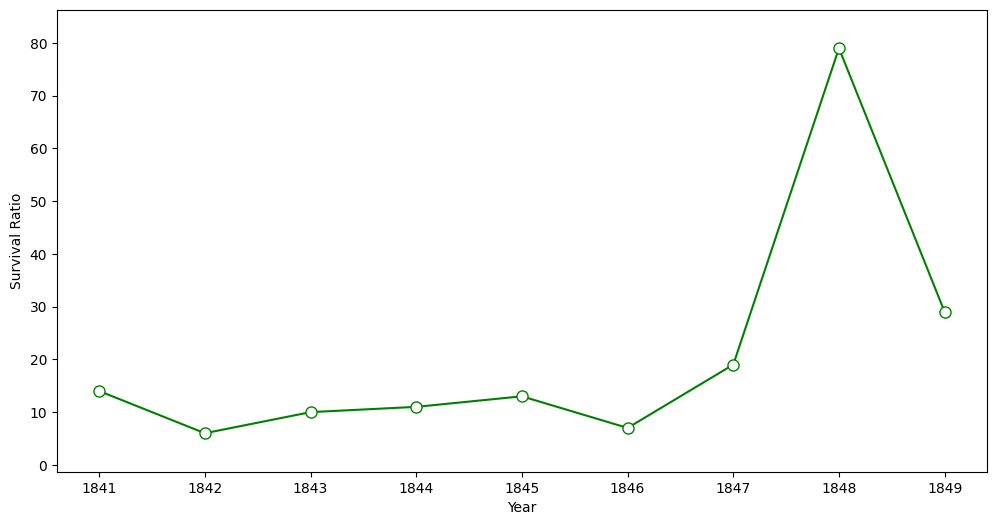

In [246]:
fig, ax = plt.subplots(figsize = [12,6])
lines = ax.plot(yearWise["year"], yearWise["survival_ratio"], color = "Green", marker = "o", mfc = "white", ms = 8)
plt.margins(y = 0.1)
plt.xlabel("Year")
plt.ylabel("Survival Ratio")
plt.show()

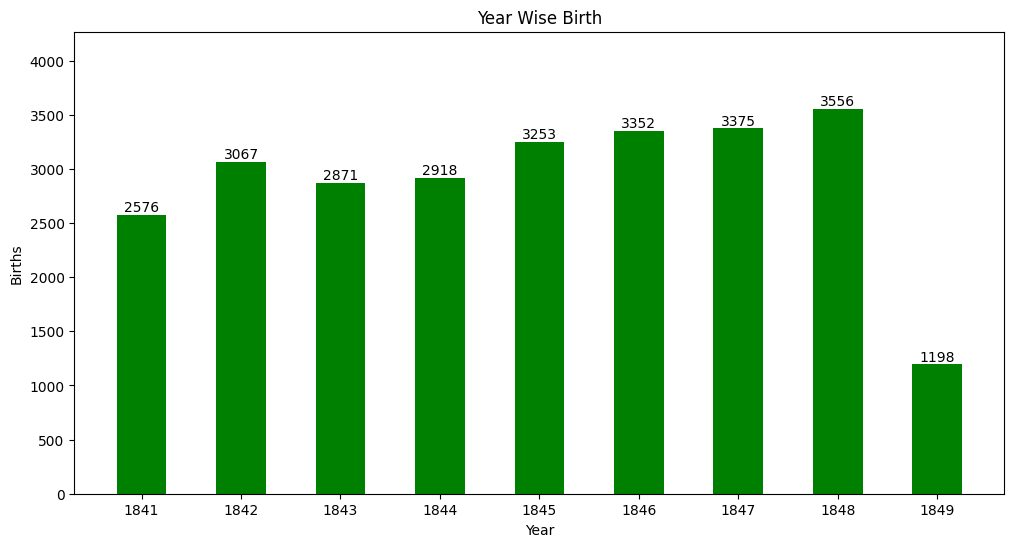

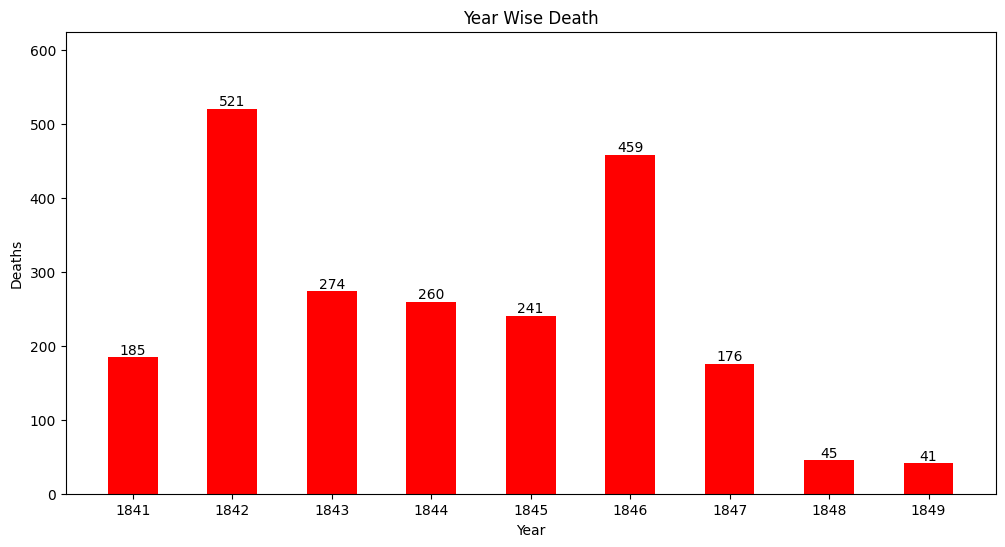

In [248]:
fig, ax = plt.subplots(figsize = [12,6])
bars = ax.bar(yearWise["year"], yearWise["total_birth"], color = "Green", width = 0.5)
ax.bar_label(bars)
ax.set_xticks(yearWise["year"])
ax.margins(y = 0.2)
plt.title("Year Wise Birth")
plt.xlabel("Year")
plt.ylabel("Births")
plt.show()


fig, ax = plt.subplots(figsize = [12,6])
bars = ax.bar(yearWise["year"], yearWise["total_death"], color = "Red", width = 0.5)
ax.bar_label(bars)
ax.set_xticks(yearWise["year"])
ax.margins(y = 0.2)
plt.title("Year Wise Death")
plt.xlabel("Year")
plt.ylabel("Deaths")
plt.show()

## yearly_deaths

In [217]:
yd

,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1
3,1844,3157,260,clinic 1
4,1845,3492,241,clinic 1
5,1846,4010,459,clinic 1
6,1841,2442,86,clinic 2
7,1842,2659,202,clinic 2
8,1843,2739,164,clinic 2
9,1844,2956,68,clinic 2


In [218]:
yd.shape

(12, 4)

In [219]:
yd.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   year    12 non-null     int64
 1   births  12 non-null     int64
 2   deaths  12 non-null     int64
 3   clinic  12 non-null     str  
dtypes: int64(3), str(1)
memory usage: 612.0 bytes


In [220]:
yd.dtypes

year      int64
births    int64
deaths    int64
clinic      str
dtype: object

In [221]:
yd.columns

Index(['year', 'births', 'deaths', 'clinic'], dtype='str')

In [222]:
yd.isnull().count()

year      12
births    12
deaths    12
clinic    12
dtype: int64

In [223]:
yd.head(3)

,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1


In [224]:
yd.tail(4)

,year,births,deaths,clinic
8,1843,2739,164,clinic 2
9,1844,2956,68,clinic 2
10,1845,3241,66,clinic 2
11,1846,3754,105,clinic 2


##### Total births of both clinic 

In [225]:
clinic_1_births = yd[yd["clinic"] == "clinic 1"]["births"].sum()
clinic_2_births = yd[yd["clinic"] == "clinic 2"]["births"].sum()

print("Total births in clinic 1 :-",clinic_1_births)
print("Total births in clinic 2 :-",clinic_2_births)

Total births in clinic 1 :- 20042
Total births in clinic 2 :- 17791


##### Total Births and Total Deaths of both clinic

In [250]:
# By using group by function 

## apply sum function on selected columns 
ans = yd.groupby("clinic", as_index = False)[["births", "deaths"]].sum()
print(ans)


print()
# By using group by function 
## apply multiple aggregate function on multiple columns 
ans = yd.groupby("clinic", as_index = False).agg(
    total_birth = ("births", "sum"), 
    total_deaths = ("deaths", "sum")
)
print(ans)

     clinic  births  deaths
0  clinic 1   20042    1989
1  clinic 2   17791     691

     clinic  total_birth  total_deaths
0  clinic 1        20042          1989
1  clinic 2        17791           691


##### clinic wise filtering

In [227]:
clinic1 = yd[yd["clinic"] == "clinic 1"]
clinic2 = yd[yd["clinic"] == "clinic 2"]

##### year wise total deaths and total births

In [252]:
yearWise = yd.groupby("year", as_index = False).agg(total_birth = ("births", "sum"), total_death = ("deaths", "sum"))

In [251]:
print(yearWise)

   year  total_birth  total_death  survival_ratio
0  1841         2576          185            14.0
1  1842         3067          521             6.0
2  1843         2871          274            10.0
3  1844         2918          260            11.0
4  1845         3253          241            13.0
5  1846         3352          459             7.0
6  1847         3375          176            19.0
7  1848         3556           45            79.0
8  1849         1198           41            29.0


##### Find the year with highest births and deaths

In [253]:
print("\n\nYear with highest births :-")
print(yearWise[yearWise["total_birth"] == yearWise["total_birth"].max()][["year", "total_birth"]])


print("\n\nYear with highest deaths :-")
print(yearWise[yearWise["total_death"] == yearWise["total_death"].max()][["year", "total_death"]])



Year with highest births :-
   year  total_birth
5  1846         7764


Year with highest deaths :-
   year  total_death
1  1842          720


In [232]:
yd["survival_ratio"] = round(yd["births"] / yd["deaths"],0)
print(yd)

    year  births  deaths    clinic  survival_ratio
0   1841    3036     237  clinic 1            13.0
1   1842    3287     518  clinic 1             6.0
2   1843    3060     274  clinic 1            11.0
3   1844    3157     260  clinic 1            12.0
4   1845    3492     241  clinic 1            14.0
5   1846    4010     459  clinic 1             9.0
6   1841    2442      86  clinic 2            28.0
7   1842    2659     202  clinic 2            13.0
8   1843    2739     164  clinic 2            17.0
9   1844    2956      68  clinic 2            43.0
10  1845    3241      66  clinic 2            49.0
11  1846    3754     105  clinic 2            36.0


In [233]:
yearWiseRatio = yd.groupby("year", as_index = False).agg(total_birth = ("births", "sum"), total_death = ("deaths", "sum")) 
yearWiseRatio["survival_ratio"] = round(yearWiseRatio["total_birth"] / yearWiseRatio["total_death"])

print(yearWiseRatio.sort_values(by = "survival_ratio", ascending = False, inplace = True)) ## inplace = True ---->>> do changes in the dataframe without returning other one

print()
print(yearWiseRatio)

None

   year  total_birth  total_death  survival_ratio
4  1845         6733          307            22.0
3  1844         6113          328            19.0
0  1841         5478          323            17.0
5  1846         7764          564            14.0
2  1843         5799          438            13.0
1  1842         5946          720             8.0


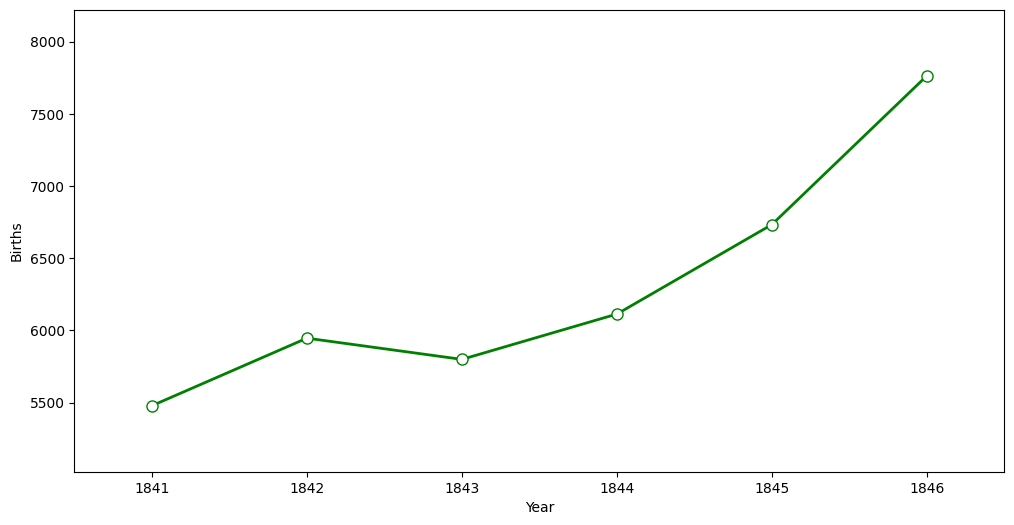

In [235]:
fig, ax = plt.subplots(figsize = [12,6])
line = ax.plot(yearWise["year"], yearWise["total_birth"], color = "Green", marker = "o", mfc = "White", ms = 8, linewidth = 2)
plt.xlabel("Year")
plt.ylabel("Births")
plt.margins(x = 0.1, y = 0.2)
plt.show()

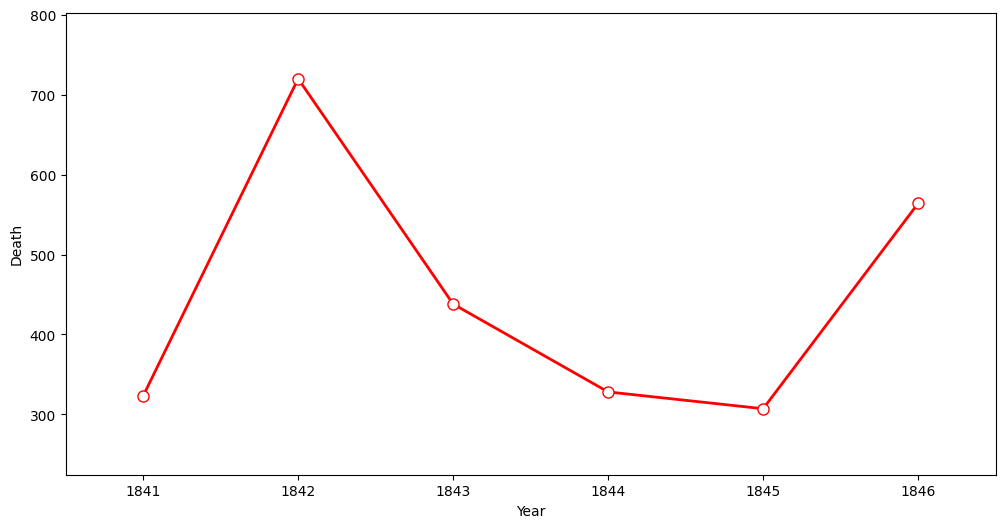

In [257]:
fig, ax = plt.subplots(figsize = [12,6])
line = ax.plot(yearWise["year"], yearWise["total_death"], color = "Red", marker = "o", mfc = "White", ms = 8, linewidth = 2)
plt.xlabel("Year")
plt.ylabel("Death")
plt.margins(x = 0.1, y = 0.2)
plt.show()

#### Year-over-Year Birth Trends of both clinic

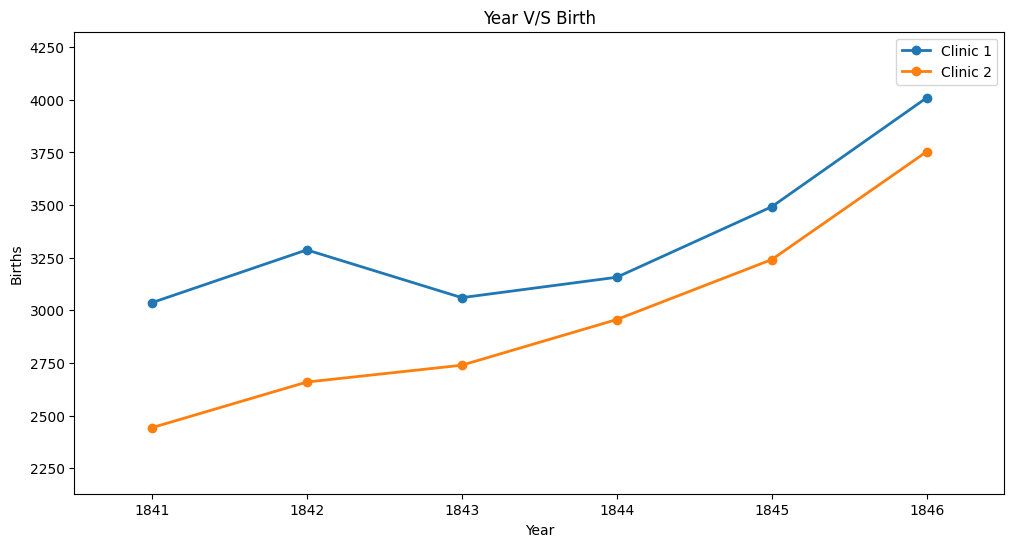

In [237]:
plt.figure(figsize = [12,6])
plt.plot(clinic1["year"], clinic1["births"], label = "Clinic 1", marker = "o", linewidth = 2, ms = 6)
plt.plot(clinic2["year"], clinic2["births"], label = "Clinic 2", marker = "o", linewidth = 2, ms = 6)
plt.title("Year V/S Birth")
plt.xlabel("Year")
plt.ylabel("Births")
plt.margins(x = 0.1, y = 0.2)
plt.legend()
plt.show()

#### Year-over-Year Death Trends of both clinic

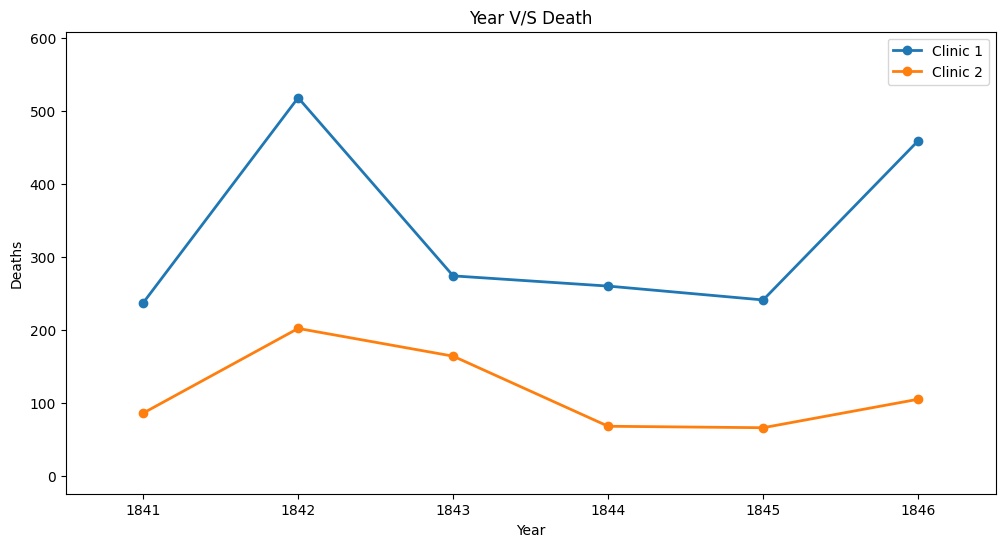

In [238]:
plt.figure(figsize = [12,6])
plt.plot(clinic1["year"], clinic1["deaths"], label = "Clinic 1", marker = "o", linewidth = 2, ms = 6)
plt.plot(clinic2["year"], clinic2["deaths"], label = "Clinic 2", marker = "o", linewidth = 2, ms = 6)
plt.title("Year V/S Death")
plt.xlabel("Year")
plt.ylabel("Deaths")
plt.margins(x = 0.1, y = 0.2)
plt.legend()
plt.show()